
# Market Maker — Debug & Notebook Version

This notebook wraps your market-making bot into a debuggable workflow with:
- **Mock Exchange**: deterministic fake order book & position to test logic offline.
- **Switchable Live/Mock Mode**: point to your real REST host, or keep it offline.
- **Verbose Logging**: see quotes, sizes, skew, and refresh logic step-by-step.
- **Metrics Capture**: record spreads, mids, inventory, and orders for analysis.
- **Unit Tests**: quick checks for pricing, skew, and clamping edge-cases.
- **Plots**: visualize mid, quoted prices, spread, skew, and inventory (matplotlib).
- **Small Run Harness**: run N iterations instead of an endless loop for faster iteration.

> Tip: Use `breakpoint()` inside the loop, or set `DEBUG=True` for extra logs.


In [137]:

import time
import math
import logging
import requests
import random
from collections import deque
from dataclasses import dataclass, field
from typing import Optional, Tuple, List, Dict

import matplotlib.pyplot as plt
from collections import deque
import time


In [162]:
API_KEY = {'X-API-Key': 'ZM53HKEZ', 'Connection': 'keep-alive'}

HOST = "http://136.152.32.17:10420"

TICKER = "ALGO"

LIVE_MODE = False

LOOPS = 99999

SLEEP = 0.05

ORDER_CAP = 5_000
INV_LIMIT = 25_000

TICK = 0.01
VOL_WIN = 60
LAMBDA = 0.2
ZVOL = 2.0
SPREAD_MIN = 0.02
SPREAD_MAX = 0.50
ALPHA_TOB = 0.5
SKEW_K = 0.75

MID_SECONDS = 20

mids_ts = deque()

STABLE_K = 0.9
UNSTABLE_K = 1.1

REG_RATIO_LOW = 0.999
REG_RATIO_HIGH = 1.001
DRIFT_Z_TH = 0.35
MIN_EWMA_FLOOR = 0.005
MIN_POINTS = 3
USE_HYSTERESIS = True
HYS_STICKINESS = 3

_last_regime = "NEUTRAL"
_last_hits = 0

MR_SPREAD_MULT = 1.20
MOM_SPREAD_MULT = 0.90
REGIME_SKEW_K = 0.25
SIZE_TILT_K = 0.25

mids_ts = deque()
mids_series = []

ticks_per_sec = None
REC_TICKS = None
PRI_TICKS = None
mids_series = []

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")
logger = logging.getLogger("mm")
DEBUG = True
if DEBUG:
    logger.setLevel(logging.DEBUG)

metrics = {
    "mid": [], "bid_px": [], "ask_px": [], "tob": [], "base_spread": [],
    "inv": [], "skew": [], "bid_qty": [], "ask_qty": [], "tick": [],
    "regime": [],
    "drift_sign": []
}

def reset_metrics():
    return {
        "mid": [], "bid_px": [], "ask_px": [], "tob": [], "base_spread": [],
        "inv": [], "skew": [], "bid_qty": [], "ask_qty": [], "tick": [],
        "regime": [],
        "drift_sign": []
    }

mids_series = []

In [163]:

# -----------------------
# Utilities
# -----------------------
def round_down(x, tick=TICK):
    return math.floor(x / tick) * tick

def round_up(x, tick=TICK):
    return math.ceil(x / tick) * tick

# -----------------------
# Volatility tracking
# -----------------------
mids_window = deque(maxlen=VOL_WIN)
ewma_abs_ret = 0.0

def update_vol(mid):
    global ewma_abs_ret
    if mids_window:
        ar = abs(mid - mids_window[-1])
        ewma_abs_ret = LAMBDA * ar + (1 - LAMBDA) * ewma_abs_ret
    mids_window.append(mid)
    return ewma_abs_ret

def dynamic_spread(a1: Optional[float], b1: Optional[float], inv: int):
    if a1 is None or b1 is None:
        return None, None, None, None, None  # insufficient book

    tob = max(a1 - b1, TICK)
    mid = 0.5 * (a1 + b1)

    vol = update_vol(mid)
    vol_spread = max(2 * ZVOL * vol, SPREAD_MIN)
    base_spread = max(SPREAD_MIN, min(SPREAD_MAX, (1 - ALPHA_TOB) * vol_spread + ALPHA_TOB * tob))

    skew = SKEW_K * (inv / INV_LIMIT) * base_spread

    raw_bid = mid - 0.5 * base_spread - skew
    raw_ask = mid + 0.5 * base_spread - skew

    bid_px = min(round_down(raw_bid, TICK), b1)
    ask_px = max(round_up(raw_ask, TICK), a1)

    if bid_px >= ask_px:
        bid_px = min(bid_px, mid - TICK)
        ask_px = max(ask_px, mid + TICK)

    return bid_px, ask_px, base_spread, tob, skew

def size_with_inventory(inv: int, q_touch: int):
    base_qty = max(100, min(q_touch, ORDER_CAP))
    bias = min(0.6, abs(inv) / INV_LIMIT)
    if inv > 0:
        bid_qty = int(base_qty * (1.0 - bias))
        ask_qty = int(base_qty * (1.0 + bias))
    elif inv < 0:
        bid_qty = int(base_qty * (1.0 + bias))
        ask_qty = int(base_qty * (1.0 - bias))
    else:
        bid_qty = ask_qty = int(base_qty)
    return max(bid_qty, 0), max(ask_qty, 0)

def clamp_qty_buyside(inv: int, desired: int):
    desired = min(desired, ORDER_CAP)
    if desired <= 0: return 0
    buy_room = INV_LIMIT - inv
    return max(0, min(desired, buy_room))

def clamp_qty_sellside(inv: int, desired: int):
    desired = min(desired, ORDER_CAP)
    if desired <= 0: return 0
    sell_room = INV_LIMIT + inv
    return max(0, min(desired, sell_room))

def _window(vals, t0, t1):
    # vals is deque of (t, mid); returns list of mids in [t0, t1]
    return [m for (t, m) in vals if t0 <= t <= t1]

def _std_abs_diff(series):
    if len(series) < 3:
        return 0.0
    diffs = [abs(series[i] - series[i-1]) for i in range(1, len(series))]
    mu = sum(diffs)/len(diffs)
    var = sum((d-mu)**2 for d in diffs)/max(1, (len(diffs)-1))
    return var**0.5


def classify_regime_tick(idx, ewma_abs_ret, mids_ts):
    """
    idx: current tick index (like 'now')
    ewma_abs_ret: EWMA of abs returns
    mids_ts: list/array of mid prices
    """
    global ticks_per_sec
    
    if ticks_per_sec is None:
        raise ValueError("Need to calibrate ticks_per_sec first!")
    
    # how many ticks back correspond to 5s and 15s
    rec_len = int(round(5.0 * ticks_per_sec))
    pri_len = int(round(15.0 * ticks_per_sec))
    
    # recent = last 5s worth of ticks
    rec_start = max(0, idx - rec_len)
    rec = mids_ts[rec_start:idx]
    
    # prior = 15s–5s ago worth of ticks
    pri_start = max(0, idx - pri_len)
    pri_end   = max(0, idx - rec_len)
    pri = mids_ts[pri_start:pri_end]
    
    if len(rec) < 3 or len(pri) < 3:
        return "NEUTRAL", 0, 0.0, 0.0
    
    rec_std = _std_abs_diff(rec)
    pri_std = _std_abs_diff(pri)
    
    stable_th   = STABLE_K   * max(1e-6, ewma_abs_ret)
    unstable_th = UNSTABLE_K * max(1e-6, ewma_abs_ret)
    
    rec_mean = sum(rec)/len(rec)
    pri_mean = sum(pri)/len(pri)
    drift = rec_mean - pri_mean
    drift_sign = 0 if abs(drift) < (0.5 * max(0.01, ewma_abs_ret)) else (1 if drift > 0 else -1)
    
    if rec_std <= stable_th and pri_std >= unstable_th:
        return "MR", drift_sign, rec_std, pri_std
    elif pri_std <= stable_th and rec_std >= unstable_th:
        return "MOM", drift_sign, rec_std, pri_std
    else:
        return "NEUTRAL", drift_sign, rec_std, pri_std
    
def classify_regime_tick(ewma_abs_ret):
    """
    Uses the last REC_TICKS as 'recent' and the prior block up to PRI_TICKS as 'prior'.
    Returns (regime, drift_sign, rec_std, pri_std).
    """
    # Need enough data
    if (REC_TICKS is None) or (PRI_TICKS is None) or (len(mids_ticks) < PRI_TICKS):
        return "NEUTRAL", 0, 0.0, 0.0

    # Convert deque -> sliceable list once
    _m = list(mids_ticks)

    rec = _m[-REC_TICKS:]                  # last ~5s
    pri = _m[-PRI_TICKS:-REC_TICKS]        # ~15s–5s ago

    if len(rec) < 3 or len(pri) < 3:
        return "NEUTRAL", 0, 0.0, 0.0

    rec_std = _std_abs_diff(rec)
    pri_std = _std_abs_diff(pri)

    stable_th   = STABLE_K   * max(1e-6, ewma_abs_ret)
    unstable_th = UNSTABLE_K * max(1e-6, ewma_abs_ret)

    rec_mean = sum(rec)/len(rec)
    pri_mean = sum(pri)/len(pri)
    drift = rec_mean - pri_mean
    drift_sign = 0 if abs(drift) < (0.5 * max(0.01, ewma_abs_ret)) else (1 if drift > 0 else -1)

    if rec_std <= stable_th and pri_std >= unstable_th:
        return "MR", drift_sign, rec_std, pri_std
    elif pri_std <= stable_th and rec_std >= unstable_th:
        return "MOM", drift_sign, rec_std, pri_std
    else:
        return "NEUTRAL", drift_sign, rec_std, pri_std

def _slice_recent_prior_from_ticks():
    """
    Return (rec, pri) where:
      rec = last REC_TICKS mids,
      pri = the REC_TICKS..PRI_TICKS-1 previous mids (i.e., ~15s–5s ago).
    Uses mids_series (list of mids by tick).
    """
    if (REC_TICKS is None) or (PRI_TICKS is None):
        return None, None
    n = len(mids_series)
    if n < PRI_TICKS:
        return None, None

    rec = mids_series[n - REC_TICKS : n]
    pri = mids_series[n - PRI_TICKS : n - REC_TICKS]
    return rec, pri


# --- single tick-based classifier (delete the other versions) ---
def classify_regime_tick(ewma_abs_ret):
    rec, pri = _slice_recent_prior_from_ticks()
    if rec is None or pri is None or len(rec) < 3 or len(pri) < 3:
        return "NEUTRAL", 0, 0.0, 0.0

    rec_std = _std_abs_diff(rec)
    pri_std = _std_abs_diff(pri)

    _ewa = max(1e-6, ewma_abs_ret)
    stable_th   = STABLE_K   * _ewa
    unstable_th = UNSTABLE_K * _ewa

    rec_mean = sum(rec) / len(rec)
    pri_mean = sum(pri) / len(pri)
    drift    = rec_mean - pri_mean
    drift_th = 0.5 * max(0.01, ewma_abs_ret)
    drift_sign = 0 if abs(drift) < drift_th else (1 if drift > 0 else -1)

    if rec_std <= stable_th and pri_std >= unstable_th:
        return "MR", drift_sign, rec_std, pri_std
    elif pri_std <= stable_th and rec_std >= unstable_th:
        return "MOM", drift_sign, rec_std, pri_std
    else:
        return "NEUTRAL", drift_sign, rec_std, pri_std
    

def classify_regime_tick(ewma_abs_ret):
    """More sensitive regime detector with ratio logic + drift z-score + optional hysteresis."""
    global _last_regime, _last_hits

    rec, pri = _slice_recent_prior_from_ticks()
    if rec is None or pri is None or len(rec) < MIN_POINTS or len(pri) < MIN_POINTS:
        _last_regime, _last_hits = "NEUTRAL", 0
        return "NEUTRAL", 0, 0.0, 0.0

    # --- vol (std of absolute diffs) ---
    rec_std = _std_abs_diff(rec)
    pri_std = _std_abs_diff(pri)

    # Guard against zeros
    eps = 1e-9
    pri_std_eff = max(pri_std, eps)
    ratio = rec_std / pri_std_eff

    # --- drift (mean difference) with z-score ---
    rec_mean = sum(rec) / len(rec)
    pri_mean = sum(pri) / len(pri)
    drift    = rec_mean - pri_mean

    # pooled scale (use local vols + small EWMA floor)
    ewa = max(MIN_EWMA_FLOOR, ewma_abs_ret)
    pooled = max(eps, 0.5 * (rec_std + pri_std) + 0.25 * ewa)  # slightly stabilised scale
    drift_z = drift / pooled

    drift_sign = 0
    if abs(drift_z) >= DRIFT_Z_TH:
        drift_sign = 1 if drift_z > 0 else -1

    # --- primary regime decision via ratio ---
    if ratio <= REG_RATIO_LOW:
        regime = "MR"
    elif ratio >= REG_RATIO_HIGH:
        regime = "MOM"
    else:
        regime = "NEUTRAL"

    # --- gentle hysteresis to reduce jitter near boundaries ---
    if USE_HYSTERESIS:
        # If we're close to a boundary, prefer sticking with last regime briefly
        near_mr  = (REG_RATIO_LOW  < ratio <= (REG_RATIO_LOW  + 0.03))
        near_mom = ((REG_RATIO_HIGH - 0.03) <= ratio < REG_RATIO_HIGH)
        if (near_mr or near_mom) and _last_regime in ("MR", "MOM"):
            _last_hits += 1
            if _last_hits <= HYS_STICKINESS:
                regime = _last_regime
        else:
            _last_hits = 0

    _last_regime = regime
    return regime, drift_sign, rec_std, pri_std





def clamp_qty(inv, desired):
    # respect per-order cap and position limit after fill
    desired = min(desired, ORDER_CAP)
    if desired <= 0: return 0
    buy_room  = INV_LIMIT - inv
    sell_room = INV_LIMIT + inv
    return max(0, min(desired, buy_room, sell_room))


ticks_per_sec = None
# --- keep your calibrate function as-is ---
def calibrate_ticks_per_sec(adapter, ticker, sleep, duration=10):
    global ticks_per_sec
    start_time = time.time()
    tick_count = 0
    while time.time() - start_time < duration:
        a1, qA1, b1, qB1 = adapter.get_book(ticker)
        tick_count += 1
        time.sleep(sleep)
    elapsed = time.time() - start_time
    ticks_per_sec = tick_count / elapsed
    print(f"[Calibration] {ticks_per_sec:.2f} ticks/sec")

# --- one copy of set_tick_windows (you had it duplicated) ---
def set_tick_windows(sec_recent=5.0, sec_prior=15.0):
    """Compute tick counts for recent/prior windows from measured ticks_per_sec."""
    global REC_TICKS, PRI_TICKS
    if ticks_per_sec is None:
        raise ValueError("ticks_per_sec not calibrated. Run calibrate_ticks_per_sec first.")
    REC_TICKS = max(3, int(round(sec_recent * ticks_per_sec)))             # ~5s
    PRI_TICKS = max(REC_TICKS + 3, int(round(sec_prior * ticks_per_sec)))  # ~15s total
    if DEBUG:
        logger.debug(f"REC_TICKS={REC_TICKS}, PRI_TICKS={PRI_TICKS} (tps={ticks_per_sec:.2f})")


def set_tick_windows(sec_recent=5.0, sec_prior=15.0):
    """Compute tick counts for recent/prior windows from measured ticks_per_sec."""
    global REC_TICKS, PRI_TICKS
    if ticks_per_sec is None:
        raise ValueError("ticks_per_sec not calibrated. Run calibrate_ticks_per_sec first.")
    REC_TICKS = max(3, int(round(sec_recent * ticks_per_sec)))         # last ~5s
    PRI_TICKS = max(REC_TICKS + 3, int(round(sec_prior * ticks_per_sec)))  # ~15s total
    if DEBUG:
        logger.debug(f"REC_TICKS={REC_TICKS}, PRI_TICKS={PRI_TICKS} (tps={ticks_per_sec:.2f})")

# --- helper to slice tick windows from mids_series ---
def _slice_recent_prior_from_ticks():
    if (REC_TICKS is None) or (PRI_TICKS is None):
        return None, None
    n = len(mids_series)
    if n < PRI_TICKS:
        return None, None
    rec = mids_series[n - REC_TICKS : n]            # last ~5s
    pri = mids_series[n - PRI_TICKS : n - REC_TICKS]# ~15s–5s ago
    return rec, pri




In [164]:

# -----------------------
# Mock Exchange Adapter
# -----------------------
@dataclass
class MockOrder:
    order_id: int
    ticker: str
    action: str  # BUY or SELL
    quantity: int
    price: float
    status: str = "OPEN"

@dataclass
class MockExchange:
    mid: float = 100.00
    spread: float = 0.04
    inv: int = 0
    next_id: int = 1
    orders: Dict[int, MockOrder] = field(default_factory=dict)

    def random_walk(self):
        # Random mid move with small jumps
        self.mid += random.choice([-1, -0.5, -0.1, 0, 0.1, 0.5, 1]) * 0.01
        self.spread = max(0.02, min(0.50, self.spread + random.choice([-1, 0, 1]) * 0.01))

    def case_tick(self):
        # simulate a tick counter increasing to 300 then stopping
        if not hasattr(self, "_tick"):
            self._tick = 0
        self._tick += 1
        return self._tick

    def get_book(self, ticker):
        a1 = round(self.mid + self.spread/2, 2)
        b1 = round(self.mid - self.spread/2, 2)
        qA1 = random.randint(200, 5000)
        qB1 = random.randint(200, 5000)
        return a1, qA1, b1, qB1

    def get_pos(self, ticker):
        return self.inv

    def list_orders(self, ticker):
        return [o for o in self.orders.values() if o.ticker == ticker and o.status in {"OPEN","ACCEPTED","PARTIAL"}]

    def cancel_order(self, order_id):
        if order_id in self.orders:
            self.orders[order_id].status = "CANCELLED"

    def cancel_all(self, ticker):
        for o in self.list_orders(ticker):
            self.cancel_order(o.order_id)

    def post_limit(self, ticker, side, qty, px):
        oid = self.next_id; self.next_id += 1
        self.orders[oid] = MockOrder(oid, ticker, side, qty, px, "OPEN")
        # Simple fill model: if we join the touch, partial fills occur
        a1, qA1, b1, qB1 = self.get_book(ticker)
        if side == "BUY" and px >= b1:
            fill = min(qty, int(qB1/2))
            self.inv += fill
        if side == "SELL" and px <= a1:
            fill = min(qty, int(qA1/2))
            self.inv -= fill
        return oid


In [165]:

# -----------------------
# Live REST Adapter (requests)
# -----------------------
class LiveAdapter:
    def __init__(self, host, headers):
        self.host = host
        self.s = requests.Session()
        self.s.headers.update(headers)
        self.s.trust_env = False
        adp = requests.adapters.HTTPAdapter(pool_connections=2, pool_maxsize=2, max_retries=0, pool_block=False)
        self.s.mount('http://', adp); self.s.mount('https://', adp)

    def case_tick(self):
        r = self.s.get(f"{self.host}/v1/case"); r.raise_for_status()
        return r.json()['tick']

    def get_book(self, ticker):
        r = self.s.get(f"{self.host}/v1/securities/book", params={"ticker": ticker}); r.raise_for_status()
        j = r.json()
        a = j['asks'][0] if j['asks'] else None
        b = j['bids'][0] if j['bids'] else None
        ask_px = a['price'] if a else None; ask_q = int(a['quantity']) if a else 0
        bid_px = b['price'] if b else None; bid_q = int(b['quantity']) if b else 0
        return ask_px, ask_q, bid_px, bid_q

    def get_pos(self, ticker):
        r = self.s.get(f"{self.host}/v1/positions", params={"ticker": ticker})
        if not r.ok: return 0
        d = r.json()
        if isinstance(d, list) and d: return int(d[0].get('position', 0))
        if isinstance(d, dict) and 'position' in d: return int(d['position'])
        return 0

    def list_orders(self, ticker):
        r = self.s.get(f"{self.host}/v1/orders", params={"ticker": ticker}); r.raise_for_status()
        return [o for o in r.json() if o.get("status") in {"OPEN","ACCEPTED","PARTIAL"}]

    def cancel_order(self, order_id):
        r = self.s.delete(f"{self.host}/v1/orders/{order_id}"); r.raise_for_status()

    def cancel_all(self, ticker):
        for o in self.list_orders(ticker):
            self.cancel_order(o["order_id"])

    def post_limit(self, ticker, side, qty, px):
        r = self.s.post(f"{self.host}/v1/orders",
                        params={"ticker": ticker, "type": "LIMIT", "quantity": qty, "price": px, "action": side})
        r.raise_for_status()
        return r.json().get("order_id")


In [166]:
def run_once(adapter, ticker=TICKER, loop_count=LOOPS, sleep=SLEEP):
    global mids_window, ewma_abs_ret, metrics, mids_ts, mids_series

    # ---- reset metrics & state for a fresh run ----
    metrics = reset_metrics()
    mids_window.clear()
    ewma_abs_ret = 0.0
    mids_ts.clear()        # timestamped mids for other logic needing wall-clock
    mids_series.clear()    # tick-indexed mids for regime windows
    # ------------------------------------------------

    last_refresh = 0.0

    def _order_action(o):
        if isinstance(o, dict):
            return o.get("action")
        return getattr(o, "action", None)

    def _order_price(o):
        if isinstance(o, dict):
            return o.get("price")
        return getattr(o, "price", None)

    for i in range(loop_count):
        now = time.time()

        if isinstance(adapter, MockExchange):
            adapter.random_walk()

        tick = adapter.case_tick()
        if tick >= 300:
            adapter.cancel_all(ticker)
            logger.info("End of case. Cancelled all and exiting.")
            break

        inv = adapter.get_pos(ticker)
        a1, qA1, b1, qB1 = adapter.get_book(ticker)

        # Need both sides to compute mid/regime
        if a1 is None or b1 is None:
            time.sleep(sleep)
            continue

        # ----- mid history -----
        mid = 0.5 * (a1 + b1)

        # keep timestamped deque for any wall-clock window logic
        mids_ts.append((now, mid))
        while mids_ts and (now - mids_ts[0][0]) > MID_SECONDS:
            mids_ts.popleft()

        # tick-indexed list for regime windows
        mids_series.append(mid)
        # (Optional) cap memory:
        # if PRI_TICKS is not None and len(mids_series) > (PRI_TICKS + VOL_WIN + 5):
        #     del mids_series[: len(mids_series) - (PRI_TICKS + VOL_WIN + 5)]

        # dynamic spread (updates EWMA via update_vol(mid) inside)
        bid_px, ask_px, base_spread, tob, skew = dynamic_spread(a1, b1, inv)

        # ----- regime classification (tick-based) -----
        regime, drift_sign, rec_std, pri_std = classify_regime_tick(ewma_abs_ret)

        metrics["regime"].append(regime)
        metrics["drift_sign"].append(drift_sign)

        # --- quoting/size logic ---
        spread_mult = 1.0
        extra_skew  = 0.0
        if regime == "MR":
            spread_mult = MR_SPREAD_MULT
            extra_skew  = REGIME_SKEW_K * drift_sign * (+1) * base_spread
        elif regime == "MOM":
            spread_mult = MOM_SPREAD_MULT
            extra_skew  = REGIME_SKEW_K * drift_sign * (-1) * base_spread

        adj_spread = max(SPREAD_MIN, min(SPREAD_MAX, base_spread * spread_mult))
        raw_bid = mid - 0.5 * adj_spread - (SKEW_K * (inv / INV_LIMIT) * base_spread + extra_skew)
        raw_ask = mid + 0.5 * adj_spread - (SKEW_K * (inv / INV_LIMIT) * base_spread + extra_skew)

        bid_px = min(round_down(raw_bid, TICK), b1)
        ask_px = max(round_up(raw_ask, TICK), a1)
        if bid_px >= ask_px:
            bid_px = min(bid_px, mid - TICK)
            ask_px = max(ask_px, mid + TICK)

        # sizes
        touch_hint = min(qA1 or ORDER_CAP, qB1 or ORDER_CAP, ORDER_CAP)
        bid_qty_raw, ask_qty_raw = size_with_inventory(inv, touch_hint)

        # regime-based size nudges
        if regime == "MR":
            if drift_sign > 0:   # recent up move
                ask_qty_raw = int(ask_qty_raw * (1 + SIZE_TILT_K))
                bid_qty_raw = int(bid_qty_raw * (1 - SIZE_TILT_K))
            elif drift_sign < 0: # recent down move
                bid_qty_raw = int(bid_qty_raw * (1 + SIZE_TILT_K))
                ask_qty_raw = int(ask_qty_raw * (1 - SIZE_TILT_K))
        elif regime == "MOM":
            if drift_sign > 0:
                bid_qty_raw = int(bid_qty_raw * (1 + SIZE_TILT_K))
                ask_qty_raw = int(ask_qty_raw * (1 - SIZE_TILT_K))
            elif drift_sign < 0:
                ask_qty_raw = int(ask_qty_raw * (1 + SIZE_TILT_K))
                bid_qty_raw = int(bid_qty_raw * (1 - SIZE_TILT_K))

        bid_qty = clamp_qty(inv, bid_qty_raw)
        ask_qty = clamp_qty(inv, ask_qty_raw)

        # orders
        open_orders = adapter.list_orders(ticker)
        bids, asks = [], []
        for o in open_orders:
            side = _order_action(o)
            if side == "BUY":
                bids.append(o)
            elif side == "SELL":
                asks.append(o)

        price_drift = False
        if len(bids) == 1 and len(asks) == 1:
            bp = _order_price(bids[0])
            ap = _order_price(asks[0])
            if bp is not None and ap is not None:
                price_drift = (abs(bp - bid_px) >= 0.02 or abs(ap - ask_px) >= 0.02)

        need_refresh = (len(bids) != 1 or len(asks) != 1)
        if need_refresh or price_drift or (now - last_refresh) > 1.5:
            adapter.cancel_all(ticker)
            if bid_qty > 0:
                adapter.post_limit(ticker, "BUY",  bid_qty, bid_px)
            if ask_qty > 0:
                adapter.post_limit(ticker, "SELL", ask_qty, ask_px)
            last_refresh = now

        # metrics
        metrics["mid"].append(mid)
        metrics["bid_px"].append(bid_px)
        metrics["ask_px"].append(ask_px)
        metrics["tob"].append(tob)
        metrics["base_spread"].append(base_spread)
        metrics["inv"].append(inv)
        metrics["skew"].append(skew)
        metrics["bid_qty"].append(bid_qty)
        metrics["ask_qty"].append(ask_qty)
        metrics["tick"].append(tick)

        time.sleep(sleep)


In [167]:
# -----------------------
# Plots (reset cleanly each call)
# -----------------------
import matplotlib.pyplot as plt

def plot_mid_and_quotes():
    plt.close('all')                          # close any previous figures
    plt.figure(figsize=(10,6))                # fresh figure
    plt.plot(metrics["tick"], metrics["mid"], label="mid")
    plt.plot(metrics["tick"], metrics["bid_px"], label="bid_px")
    plt.plot(metrics["tick"], metrics["ask_px"], label="ask_px")
    plt.legend()
    plt.title("Mid and Quoted Prices")
    plt.xlabel("tick")
    plt.ylabel("price")
    plt.show()

def plot_spreads():
    plt.close('all')
    plt.figure(figsize=(10,6))
    plt.plot(metrics["tick"], metrics["base_spread"], label="base_spread")
    plt.plot(metrics["tick"], metrics["tob"], label="top_of_book_spread")
    plt.legend()
    plt.title("Spreads (base vs TOB)")
    plt.xlabel("tick")
    plt.ylabel("spread")
    plt.show()

def plot_inventory_and_sizes():
    plt.close('all')
    plt.figure(figsize=(10,6))
    plt.plot(metrics["tick"], metrics["inv"], label="inventory")
    plt.legend()
    plt.title("Inventory")
    plt.xlabel("tick")
    plt.ylabel("shares")
    plt.show()

    plt.figure(figsize=(10,6))
    plt.plot(metrics["tick"], metrics["bid_qty"], label="bid_qty")
    plt.plot(metrics["tick"], metrics["ask_qty"], label="ask_qty")
    plt.legend()
    plt.title("Quote Sizes")
    plt.xlabel("tick")
    plt.ylabel("shares")
    plt.show()

def plot_skew():
    plt.close('all')
    plt.figure(figsize=(10,6))
    plt.plot(metrics["tick"], metrics["skew"], label="skew")
    plt.legend()
    plt.title("Price Skew")
    plt.xlabel("tick")
    plt.ylabel("dollars")
    plt.show()

def plot_regime_timeline():
    plt.close('all')
    plt.figure(figsize=(10,6))

    ticks = metrics["tick"]
    regimes = metrics["regime"]

    # Build boolean masks
    neutral_mask = [r == "NEUTRAL" for r in regimes]
    mom_mask     = [r == "MOM"     for r in regimes]
    mr_mask      = [r == "MR"      for r in regimes]

    # Scatter at fixed y-levels (0=NEUTRAL, 1=MOM, 2=MR)
    plt.scatter([t for t, m in zip(ticks, neutral_mask) if m],
                [0]*sum(neutral_mask), label="NEUTRAL", s=10)
    plt.scatter([t for t, m in zip(ticks, mom_mask) if m],
                [1]*sum(mom_mask),     label="MOM",     s=10)
    plt.scatter([t for t, m in zip(ticks, mr_mask) if m],
                [2]*sum(mr_mask),      label="MR",      s=10)

    # Nice y-ticks
    plt.yticks([0,1,2], ["NEUTRAL","MOM","MR"])
    plt.title("Regime Timeline")
    plt.xlabel("tick")
    plt.ylabel("regime")
    plt.legend()
    plt.show()



In [168]:

# -----------------------
# Quick Unit Tests
# -----------------------
def test_clamp():
    # Long inventory reduces buy room, shouldn't cap sell side
    inv = 20_000
    assert clamp_qty_buyside(inv, 5000) <= (INV_LIMIT - inv)
    assert clamp_qty_sellside(inv, 5000) <= (INV_LIMIT + inv)

def test_dynamic_spread_basic():
    # With symmetric a1/b1 and zero inv, bid<ask spaced by base_spread
    a1, b1 = 100.02, 99.98
    inv = 0
    bid, ask, spr, tob, skew = dynamic_spread(a1, b1, inv)
    assert bid < ask
    assert spr >= SPREAD_MIN
    assert abs(skew) < 1e-9

def run_tests():
    test_clamp()
    test_dynamic_spread_basic()
    print("All tests passed.")

run_tests()


All tests passed.


2025-09-25 18:41:39,788 DEBUG: REC_TICKS=93, PRI_TICKS=280 (tps=18.69)


[Calibration] 18.69 ticks/sec


2025-09-25 18:41:55,748 INFO: End of case. Cancelled all and exiting.


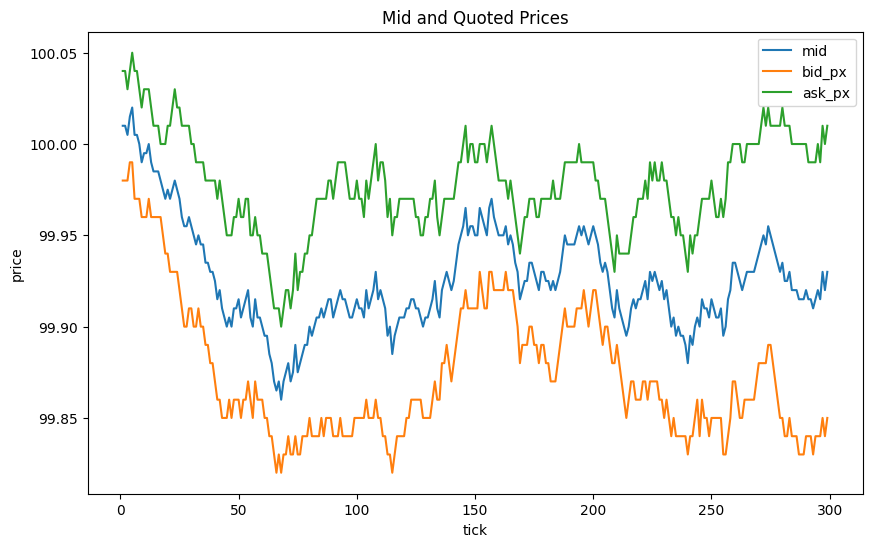

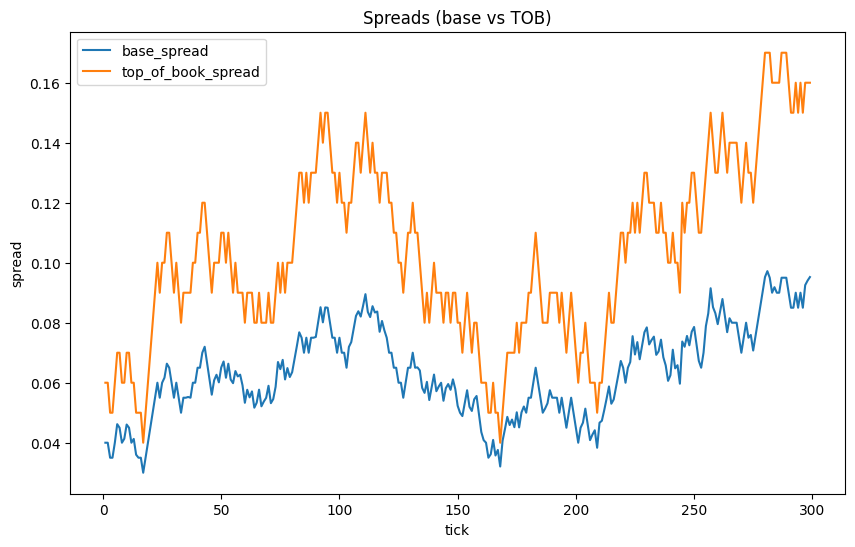

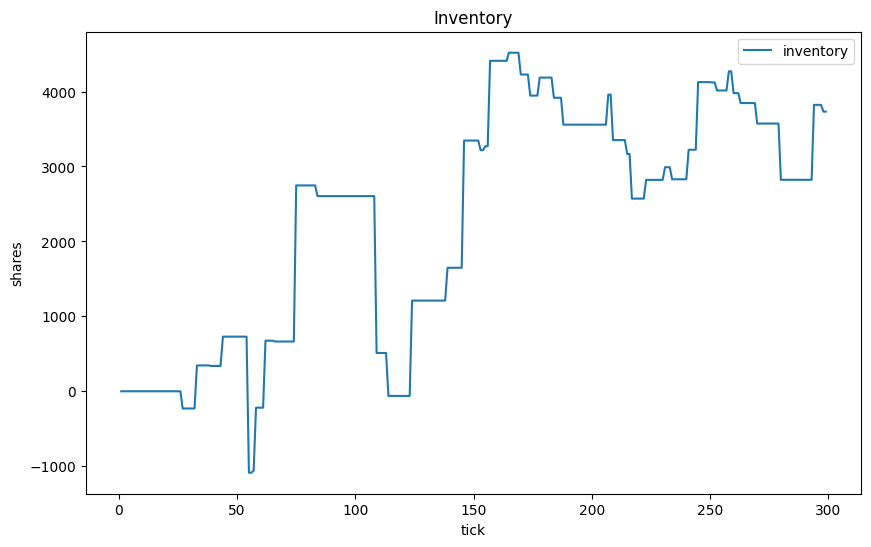

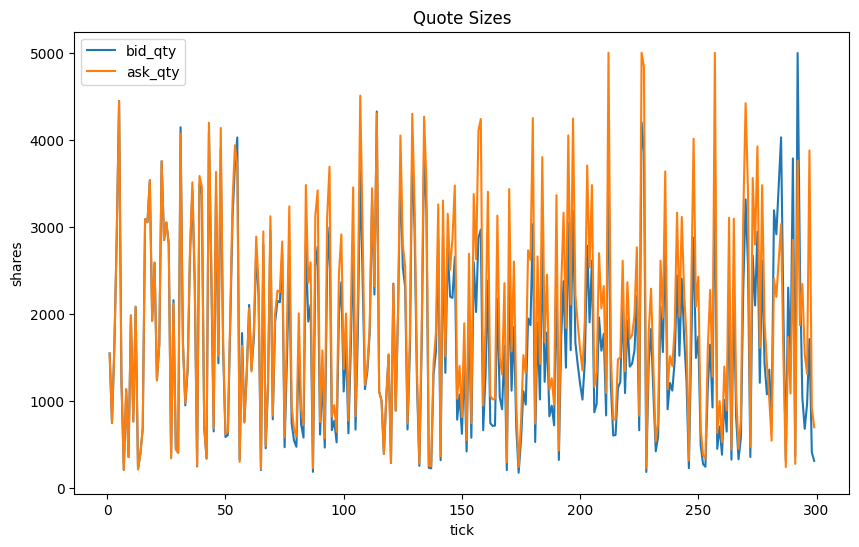

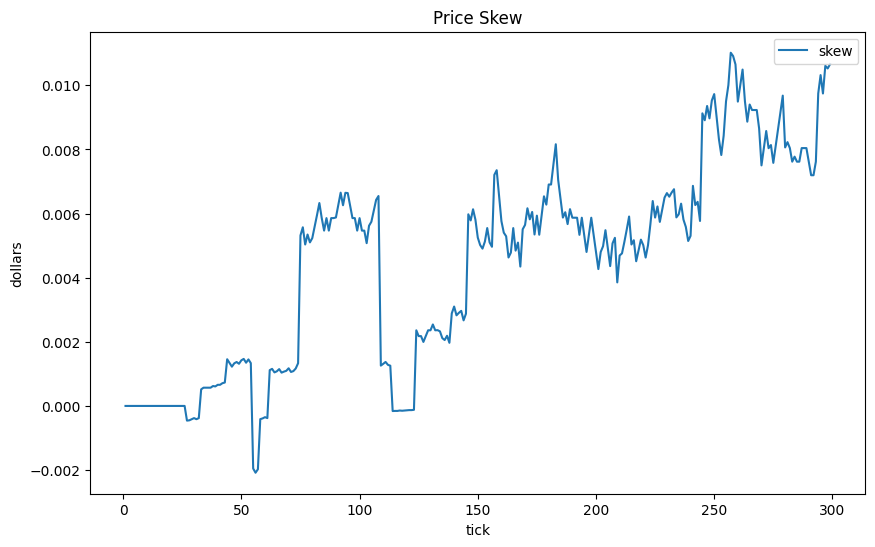

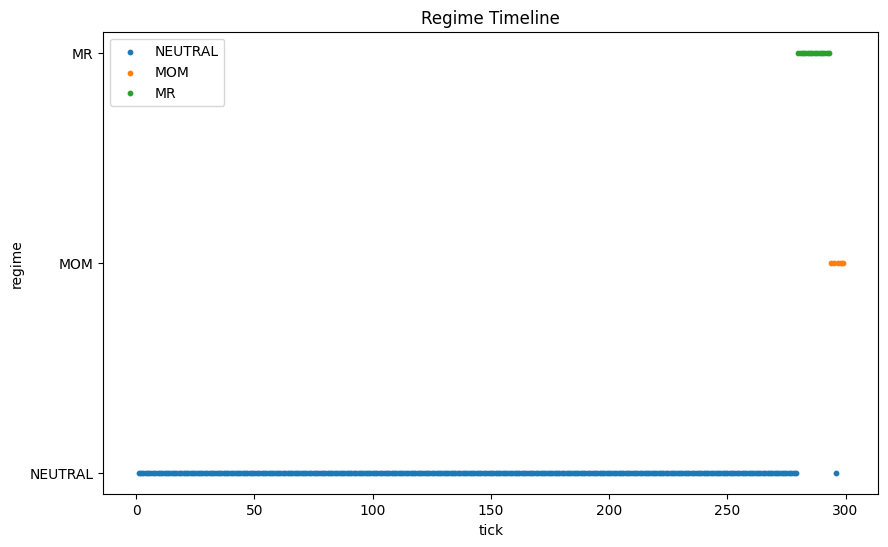

In [169]:

# -----------------------
# Select Adapter & Run
# -----------------------
# Before run_once
adapter = LiveAdapter(HOST, API_KEY) if LIVE_MODE else MockExchange()

calibrate_ticks_per_sec(adapter, TICKER, SLEEP, duration=10)  # sets ticks_per_sec
set_tick_windows(sec_recent=5.0, sec_prior=15.0)              # sets REC_TICKS/PRI_TICKS

run_once(adapter, TICKER, LOOPS, SLEEP)


# Example: plots for quick sanity checks
plt.close('all')
plot_mid_and_quotes()
plot_spreads()
plot_inventory_and_sizes()
plot_skew()
plot_regime_timeline()
